# Data Feature Analysis (DFA) — Indian Personal Finance & Spending Habits


## 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv('indianPersonalFinanceAndSpendingHabits.csv')

## 2 — Data Overview

In [5]:
print("SHAPE")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print()

print("DATA TYPES")
print(df.dtypes.value_counts())
print()

print("MISSING VALUES")
missing = df.isnull().sum()
print(f"Total missing cells: {missing.sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values — dataset is complete.")
print()

print("DUPLICATES")
print(f"Duplicate rows: {df.duplicated().sum()}")

SHAPE
Rows: 20,000  |  Columns: 27

DATA TYPES
float64    23
int64       2
object      2
Name: count, dtype: int64

MISSING VALUES
Total missing cells: 0
No missing values — dataset is complete.

DUPLICATES
Duplicate rows: 0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

In [7]:
df.head(10)

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076
5,24875.610267,57,4,Self_Employed,Tier_2,4975.122053,0.000000,1038.230996,3250.067756,1760.164812,...,1478.666359,7599.265300,957.619116,521.683848,135.925865,148.952326,86.567256,13.143683,33.961843,96.675925
6,106119.692762,53,0,Self_Employed,Tier_2,21223.938552,0.000000,4360.202710,12790.390693,6345.738036,...,18399.564592,41595.325723,2799.234658,912.958599,438.009790,541.702363,838.299989,111.857588,0.000000,409.453143
7,55431.341508,40,1,Professional,Tier_2,11086.268302,8307.702220,1755.439820,8194.482410,3353.001888,...,6636.413893,8465.944597,1059.499640,838.163700,466.179258,327.902059,353.411650,92.739538,116.121727,71.520963
8,20606.733121,32,4,Retired,Tier_1,6182.019936,3562.488826,1018.589940,3066.867220,1170.790666,...,362.917872,362.917872,822.974023,212.998059,85.489142,97.812946,252.344383,9.984250,59.957848,80.754353
9,46304.790235,30,1,Student,Tier_2,9260.958047,0.000000,2130.254825,5065.627032,2500.054847,...,5615.104745,15690.256276,962.019888,380.272262,598.882904,188.311642,793.644470,34.873044,39.738841,203.146675


## 3 — Categorical Feature Analysis

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

for col in cat_cols:
    print(f"--- {col} ---")
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'count': vc, 'pct': pct}))
    print()

Categorical columns: ['Occupation', 'City_Tier']

--- Occupation ---
               count   pct
Occupation                
Retired         5019  25.1
Professional    5011  25.1
Student         5003  25.0
Self_Employed   4967  24.8

--- City_Tier ---
           count   pct
City_Tier             
Tier_2     10068  50.3
Tier_1      5934  29.7
Tier_3      3998  20.0



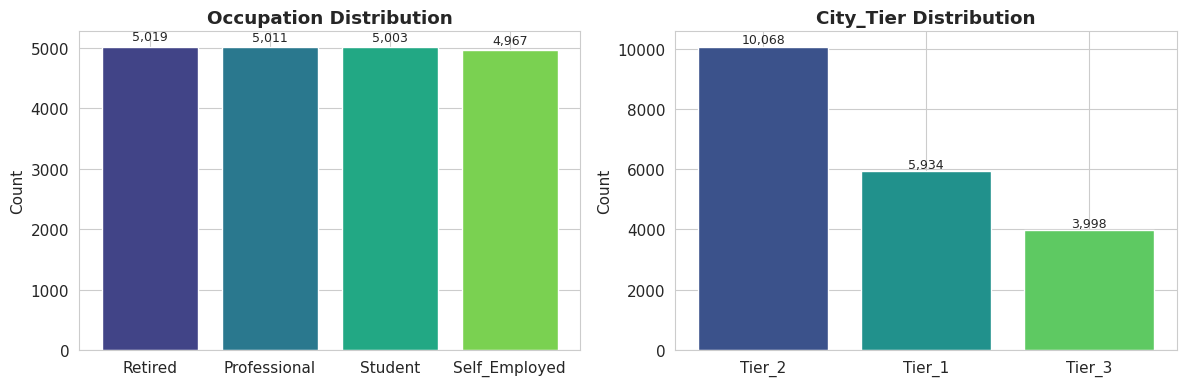

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color=sns.color_palette('viridis', len(vc)))
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{int(bar.get_height()):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4 — Distribution of Key Numerical Features

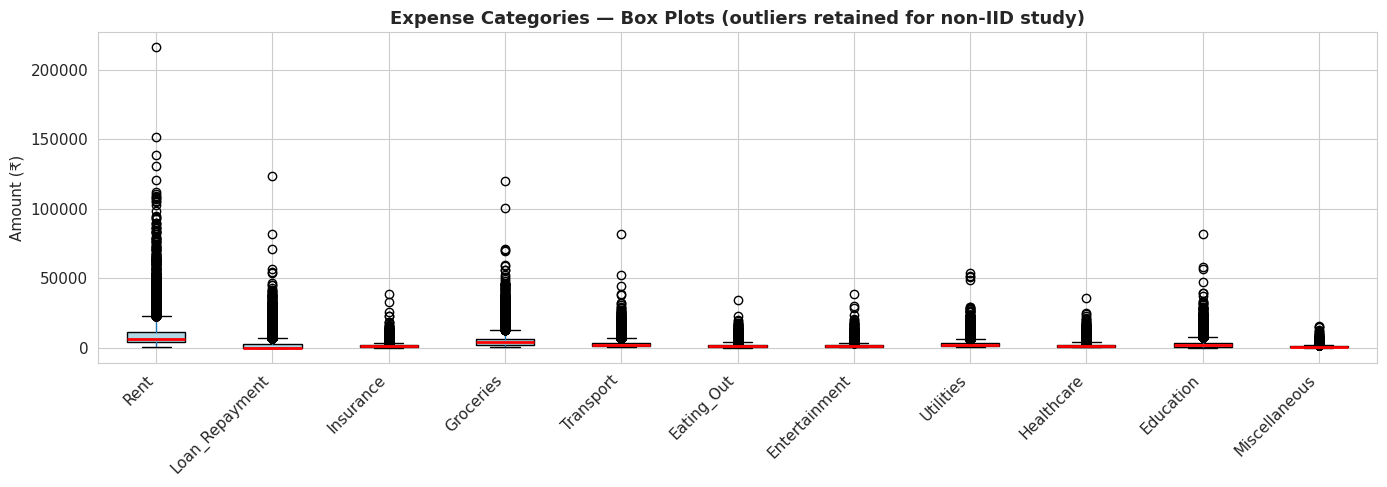

In [11]:
# Box plots for expense columns — shows natural spread (no outlier removal)
expense_cols = ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
                'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare',
                'Education', 'Miscellaneous']

fig, ax = plt.subplots(figsize=(14, 5))
df[expense_cols].boxplot(ax=ax, vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue'),
                         medianprops=dict(color='red', lw=2))
ax.set_title('Expense Categories — Box Plots (outliers retained for non-IID study)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Amount (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5 — Correlation Analysis

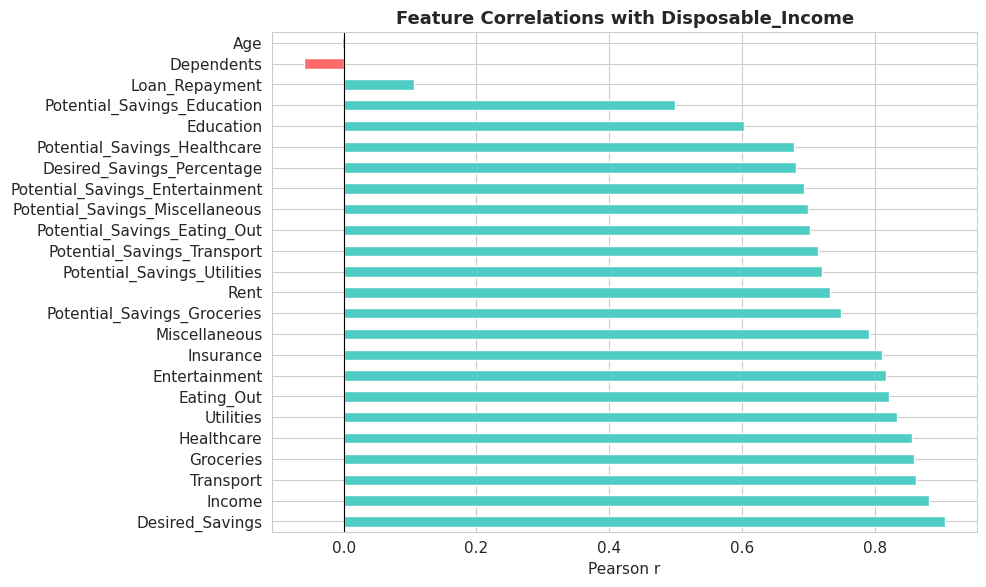

Top 5 positive correlations:
Desired_Savings    0.9058
Income             0.8815
Transport          0.8615
Groceries          0.8586
Healthcare         0.8569

Top 5 negative correlations:
Dependents   -0.0595
Age          -0.0026


In [15]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

# Top correlations with the target variable
target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4ecdc4' if v > 0 else '#ff6b6b' for v in target_corr]
target_corr.plot.barh(ax=ax, color=colors)
ax.set_title(f'Feature Correlations with {target}', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print('Top 5 positive correlations:')
print(target_corr.head().round(4).to_string())
print('\nTop 5 negative correlations:')
print(target_corr[target_corr < 0].head().round(4).to_string())


## 6 — Non-IID Heterogeneity Analysis

This section examines how the data naturally partitions across the categorical dimensions used for federated client assignment: **Occupation**, **City_Tier**, and **Income_Bracket**.

In [16]:
# Engineer the same partitioning features used in the FL pipeline
df['Total_Expenses'] = df[['Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
                            'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
                            'Healthcare', 'Education', 'Miscellaneous']].sum(axis=1)
df['Actual_Savings'] = df['Income'] - df['Total_Expenses']
df['Actual_Savings_Rate'] = (df['Actual_Savings'] / df['Income']) * 100
df['Income_Bracket'] = pd.qcut(df['Income'], q=3, labels=['Low', 'Medium', 'High'])
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])

print("Engineered columns added: Total_Expenses, Actual_Savings, Actual_Savings_Rate, Income_Bracket, Age_Group")

Engineered columns added: Total_Expenses, Actual_Savings, Actual_Savings_Rate, Income_Bracket, Age_Group


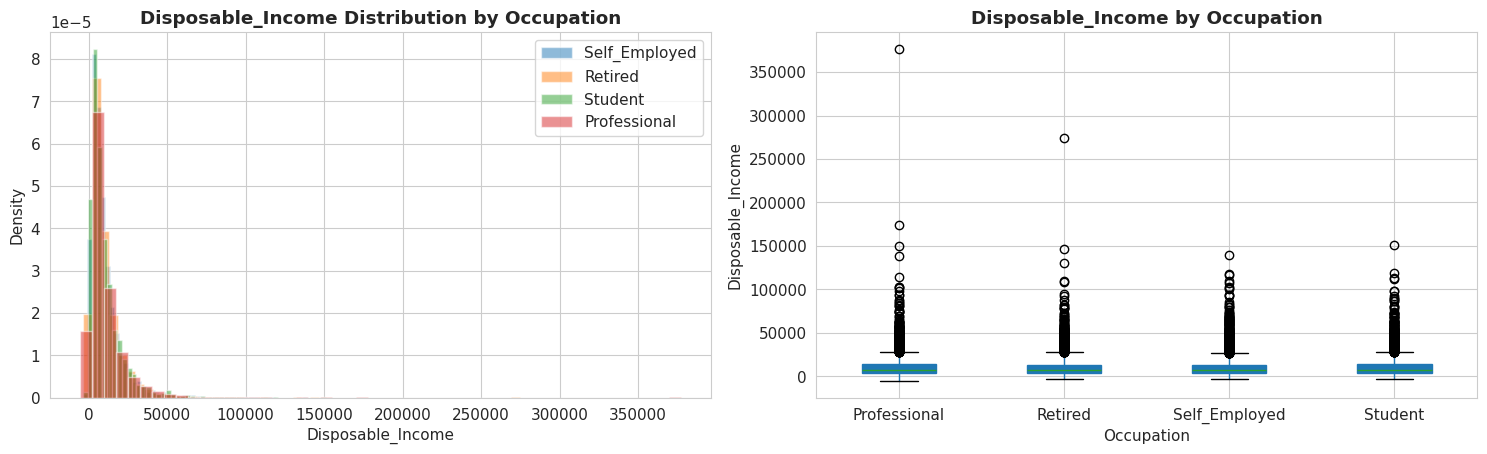

                   mean   median       std  count
Occupation                                       
Professional   10788.19  7332.05  12637.24   5011
Retired        10418.14  7161.73  11335.41   5019
Self_Employed  10643.88  7263.49  11467.27   4967
Student        10739.75  7155.22  11473.08   5003


In [17]:
# Disposable Income distribution by Occupation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for occ in df['Occupation'].unique():
    subset = df[df['Occupation'] == occ][target]
    axes[0].hist(subset, bins=50, alpha=0.5, label=occ, density=True)
axes[0].set_title(f'{target} Distribution by Occupation', fontweight='bold')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Density')
axes[0].legend()

df.boxplot(column=target, by='Occupation', ax=axes[1], patch_artist=True)
axes[1].set_title(f'{target} by Occupation', fontweight='bold')
plt.suptitle('')
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel(target)

plt.tight_layout()
plt.show()

print(df.groupby('Occupation')[target].agg(['mean', 'median', 'std', 'count']).round(2))


In [20]:
# Combined partition key analysis (mirrors FL pipeline partitioning)
df['Partition_Key'] = df['Occupation'] + '_' + df['City_Tier'] + '_' + df['Income_Bracket'].astype(str)

partition_stats = df.groupby('Partition_Key')[target].agg(['mean', 'std', 'count']).round(2)
partition_stats = partition_stats.sort_values('mean', ascending=False)

print(f'Number of unique partition keys: {partition_stats.shape[0]}')
print(f'Min samples per partition: {partition_stats["count"].min()}')
print(f'Max samples per partition: {partition_stats["count"].max()}')
print(f'Mean of target across partitions — range: [{partition_stats["mean"].min():,.0f}, {partition_stats["mean"].max():,.0f}]')
print()
partition_stats


Number of unique partition keys: 36
Min samples per partition: 320
Max samples per partition: 874
Mean of target across partitions — range: [2,334, 27,427]



,mean,std,count
Partition_Key,,,
Professional_Tier_3_High,27426.88,16384.43,367
Retired_Tier_3_High,26934.65,21738.79,320
Student_Tier_3_High,26434.13,15840.99,332
Self_Employed_Tier_3_High,25347.75,15581.54,329
Self_Employed_Tier_2_High,22592.29,15538.68,854
Student_Tier_2_High,22509.33,14501.93,841
Professional_Tier_2_High,22220.73,18920.26,836
Retired_Tier_2_High,21473.23,12725.88,847
Student_Tier_1_High,14629.75,11340.83,500
